<a href="https://colab.research.google.com/github/padmacharan-123/APPLIED-AI-REC-1/blob/main/Viola_jones.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python matplotlib scikit-learn tensorflow

import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
lfw = fetch_lfw_people(min_faces_per_person=20, resize=0.4)

X = lfw.images   # grayscale images
y = np.ones(len(X))  # label all as face (1)

print("Dataset shape:", X.shape)

Dataset shape: (3023, 50, 37)


In [3]:
# Generate random noise images as NON-FACE
non_faces = np.random.rand(len(X), X.shape[1], X.shape[2])

X_full = np.concatenate([X, non_faces])
y_full = np.concatenate([np.ones(len(X)), np.zeros(len(non_faces))])

In [4]:
# Resize to 64x64
X_resized = np.array([cv2.resize(img, (64,64)) for img in X_full])

# Normalize
X_resized = X_resized / 255.0

# Add channel dimension
X_resized = X_resized.reshape(-1, 64, 64, 1)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resized, y_full, test_size=0.2
)

In [5]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64,64,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,624,705 (6.20 MB)

 Trainable params: 1,624,705 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.6022 - loss: 0.6706 - val_accuracy: 0.8752 - val_loss: 0.5189
Epoch 2/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9665 - loss: 0.1825 - val_accuracy: 0.9843 - val_loss: 0.0902
Epoch 3/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9851 - loss: 0.0643 - val_accuracy: 0.9769 - val_loss: 0.0584
Epoch 4/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9876 - loss: 0.0473 - val_accuracy: 0.9777 - val_loss: 0.0711
Epoch 5/5
152/152 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9899 - loss: 0.0391 - val_accuracy: 0.9884 - val_loss: 0.0408


In [7]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

Saving a-diverse-group-of-business-people-poses-for-a-professional-team-exuding-confidence-and-professionalism-ai-generative-photo.jpg to a-diverse-group-of-business-people-poses-for-a-professional-team-exuding-confidence-and-professionalism-ai-generative-photo.jpg


(np.float64(-0.5), np.float64(3028.5), np.float64(1959.5), np.float64(-0.5))

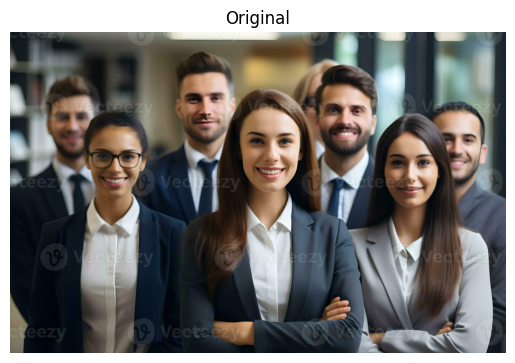

In [8]:
from google.colab import files
uploaded = files.upload()

img = cv2.imread(list(uploaded.keys())[0])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original")
plt.axis('off')

In [9]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Integral Image
integral_img = cv2.integral(gray)

print("Integral Image Computed")

Integral Image Computed


(np.float64(-0.5), np.float64(3028.5), np.float64(1959.5), np.float64(-0.5))

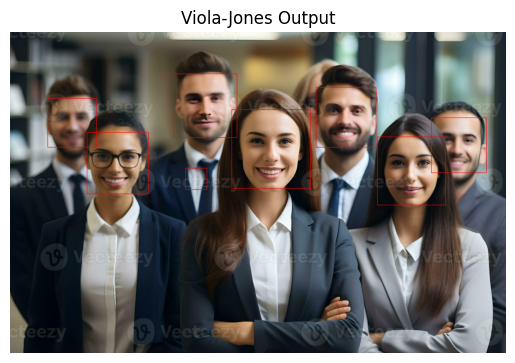

In [10]:
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

output = img_rgb.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(output, (x,y), (x+w,y+h), (255,0,0), 2)

plt.imshow(output)
plt.title("Viola-Jones Output")
plt.axis('off')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 673ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


(np.float64(-0.5), np.float64(3028.5), np.float64(1959.5), np.float64(-0.5))

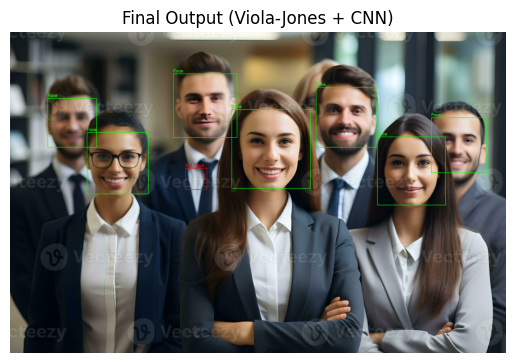

In [11]:
final_output = img_rgb.copy()

for (x, y, w, h) in faces:
    face_crop = gray[y:y+h, x:x+w]
    face_crop = cv2.resize(face_crop, (64,64))
    face_crop = face_crop / 255.0
    face_crop = face_crop.reshape(1,64,64,1)

    pred = model.predict(face_crop)

    if pred > 0.5:
        label = "Face"
        color = (0,255,0)
    else:
        label = "Not Face"
        color = (255,0,0)

    cv2.rectangle(final_output, (x,y), (x+w,y+h), color, 2)
    cv2.putText(final_output, label, (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)

plt.imshow(final_output)
plt.title("Final Output (Viola-Jones + CNN)")
plt.axis('off')